In [54]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import cftime

from ep_processing import *
from utils.visualization import * 

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

In [55]:
my_experiment_name = "amip"
my_runid = "agm-amip-test"

# my_base_path = "/scratch/agmorgan/canesm_runs/{runid}/data/nc_output/CMIP6/CMIP/CP4C/CanESM5-1/{experiment_name}/r1i1p1f1/"
# my_daily_path = "day/{var_name}/gn/v20190429/{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"

my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_file_path = "{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"

year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

conv = 86400. 

# All precip
ds_pr_daily = conv * get_ds(
                    "pr",
                    my_runid, 
                    my_experiment_name,
                    year_range,
                    base_path = my_base_path,
                    file_path = my_file_path,
)

# Convective precip 
ds_prc_daily = conv * get_ds(
                    "prc",
                    my_runid, 
                    my_experiment_name,
                    year_range,
                    base_path = my_base_path,
                    file_path = my_file_path,
)

In [47]:
def get_day_of_extreme(da, year):
    return select_fixed_year(da, year).idxmax(dim = "time")

In [63]:
da_epr_as_temporal_list = []
da_eprc_as_temporal_list = []

for year in year_range:
    day_of_epe = get_day_of_extreme(ds_pr_daily.pr, year)
    
    da_epr_current_year = ds_pr_daily.pr.sel(time = day_of_epe)
    da_eprc_current_year = ds_prc_daily.prc.sel(time = day_of_epe)
    
    da_epr_as_temporal_list.append(da_epr_current_year)
    da_eprc_as_temporal_list.append(da_eprc_current_year)

In [64]:
def to_yearly_dataarray(da, da_processed, year_range):
    return xr.DataArray(
            data = da_processed,
            dims = ["time", "lat", "lon"],
            coords = dict(
                lon = da.lon.to_numpy(),
                lat = da.lat.to_numpy(),
                time = [year for year in year_range],
            ),
        )

In [70]:
da_epr = to_yearly_dataarray(ds_pr_daily.pr, da_epr_as_temporal_list, year_range)
da_eprc = to_yearly_dataarray(ds_prc_daily.prc, da_eprc_as_temporal_list, year_range)
da_eprr = da_epr - da_eprc

In [71]:
da_epr_mean = da_epr.mean(dim = "time")
da_eprc_mean = da_eprc.mean(dim = "time")
da_eprr_mean = da_eprr.mean(dim = "time")

da_epr_max = da_epr_mean.max().values

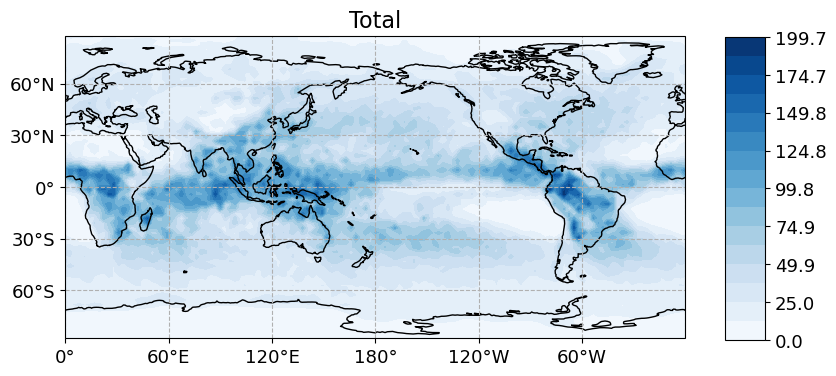

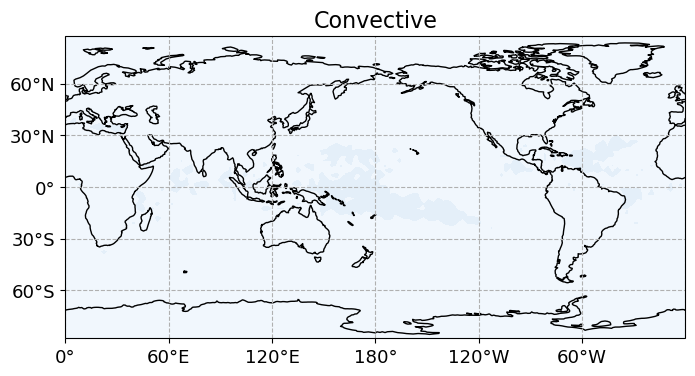

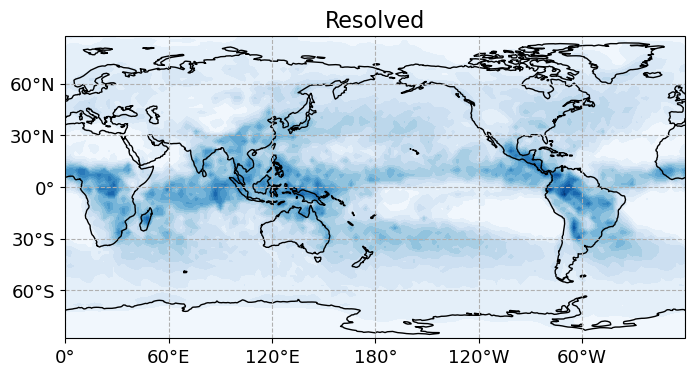

In [74]:
da_list = [da_epr_mean, da_eprc_mean, da_eprr_mean]
label_list = ["Total", "Convective", "Resolved"]

for da, label in zip(da_list, label_list):

    field_vals, lon_plt, lat_plt = process_for_map(da)
    draw_global_map(
        lon_plt,
        lat_plt,
        field_vals,
        title = label,
        filled = True,
        show_fig = False,
        save_fig = True,
        levels = 16,
        cmap = "Blues",
        cbar_params = [0.95, 0.24, 0.05, 0.505], # position, upper offset, width, cbar length
        vmin = 0,
        vmax = da_epr_max,
        draw_labels = False,
        label_contours = False,
        remove_cbar = True if label != "Total" else False,
        fig = None,
        projection = ccrs.PlateCarree(central_longitude = 180),
        outfilename = "amip_baseline_experiment1" + label + ".png",
    )

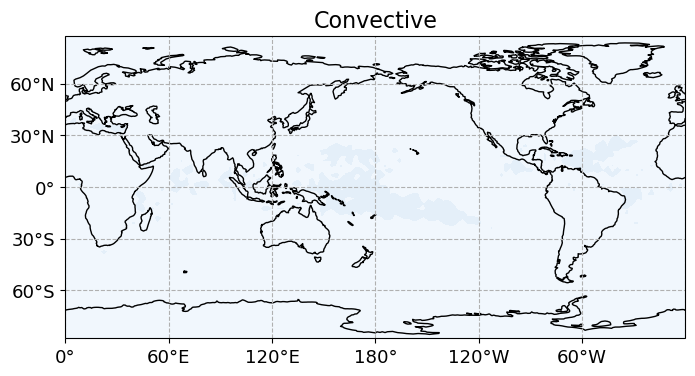

In [69]:
field_vals, lon_plt, lat_plt = process_for_map(da_eprc_mean)
label = "Convective"
draw_global_map(
        lon_plt,
        lat_plt,
        field_vals,
        title = label,
        filled = True,
        show_fig = True,
        save_fig = False,
        levels = 16,
        cmap = "Blues",
        cbar_params = [0.95, 0.24, 0.05, 0.505], # position, upper offset, width, cbar length
        vmin = 0,
        vmax = da_epr_max,
        draw_labels = False,
        label_contours = False,
        remove_cbar = True if label != "Total" else False,
        fig = None,
        projection = ccrs.PlateCarree(central_longitude = 180),
        outfilename = "amip_baseline_experiment1" + label + ".png",
)

NameError: name 'da_eprr' is not defined

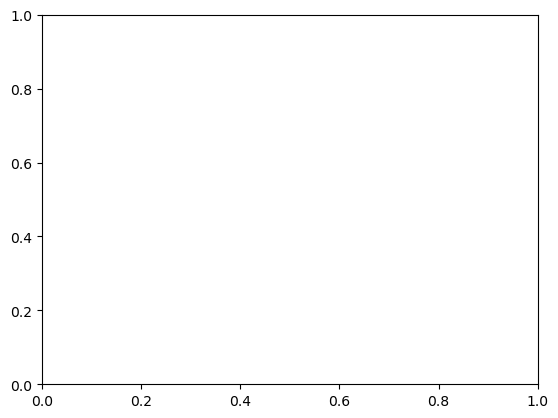

In [51]:
fig, ax = plt.subplots()
CS = da_eprr.plot(vmin=0, vmax=da_eprr_max, cbar_kwargs={"label": "pr resolved (mm/d)"})
plt.title("Resolved")
plt.show()

Check mean precipitation time series against benchmarks available on the [RTD browser](http://206.12.97.61:8500/). 

In [75]:
# my_ areacell_path = "fx/areacella/gn/v20190429/areacella_fx_CanESM5-1_{experiment_name}_r1i1p1f1_gn.nc"
my_areacell_path = "areacella_fx_CanESM5-1_amip_r1i1p1f1_gn.nc"

ds_areacella = get_ds_areacell(
                    my_runid, 
                    my_experiment_name,
                    base_path = my_base_path,
                    areacell_path = my_areacell_path,
)
global_area = ds_areacella.areacella.sum(dim=['lon', 'lat'])         

np.float32(248192.8)

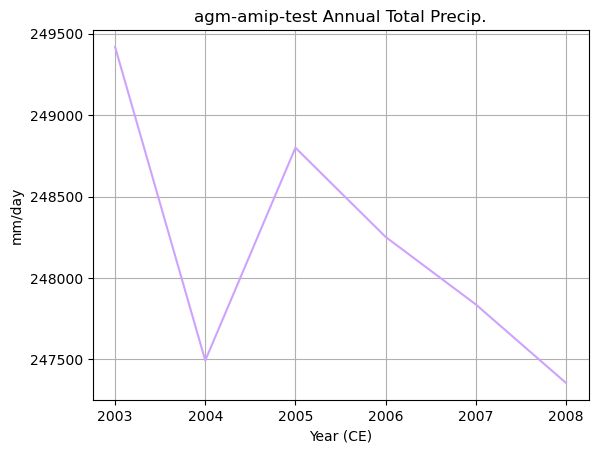

In [76]:
pr_gm = (ds_areacella.areacella * ds_pr_daily.pr).sum(dim=['lon', 'lat']) / global_area # Properly area weighted mean of rate of flux
time_scale = 60*60*24 # Number of seconds in a day 
(time_scale*pr_gm.groupby('time.year').mean(dim='time')).plot(color="xkcd:lilac")
plt.grid()
plt.title("agm-amip-test Annual Total Precip.")
plt.xlabel("Year (CE)")
plt.ylabel("mm/day")
pr_mean = time_scale*pr_gm.mean(dim='time').values
pr_mean